# Big Data Analysis
## MapReduce in Python

Goal for today:
- Understand the three phases of MapReduce: map, shuffle and reduce
- Build a small MapReduce "machine" in Python from scratch
- Write your own mappers and reducers for questions about a real dataset
- Understand why a distributed average must carry (sum, count)
- Recognise when a question needs two MapReduce jobs, one after the other

How to use this notebook:
- Run cells top to bottom
- Sections 1 to 8 are core: read them and run the examples
- Exercises are labelled Practice or Challenge (optional)
- Where you see `# TODO`, write your own code; each exercise shows the expected output
- Focus on understanding the pattern (what is the key? what is the value?), not just on getting the right answer

Dataset
- Wikipedia movie plots (one row per movie), the same dataset as last week
- We use the title, release year, origin, director, genre and plot

___

Where this fits:
- Week 1: some files are too big for Excel, or even for one computer
- Week 2: map, filter, lambda and pure functions
- Week 3 (today): MapReduce, many machines working on one dataset, built from those same ideas
- Week 4: Spark, which runs MapReduce-style jobs for you on a real cluster

___

In [1]:
import string
from collections import defaultdict

import matplotlib.pyplot as plt
import nltk
import pandas as pd

DATA_PATH = "../week02/wiki_movie_plots_deduped.csv"

# If you keep the CSV elsewhere, update DATA_PATH.

df_raw = pd.read_csv(DATA_PATH)
df_raw.shape

(34886, 8)

In [2]:
# Column names in the Kaggle dataset
YEAR_COL = "Release Year"
TITLE_COL = "Title"
ORIGIN_COL = "Origin/Ethnicity"
DIRECTOR_COL = "Director"
GENRE_COL = "Genre"
PLOT_COL = "Plot"

# One movie = one dictionary, many movies = a list of dictionaries (as in week 2)
movies = df_raw[[YEAR_COL, TITLE_COL, ORIGIN_COL, DIRECTOR_COL, GENRE_COL, PLOT_COL]].to_dict("records")
titles = [m[TITLE_COL] for m in movies]

print("Rows:", len(movies))
movies[0]

Rows: 34886


{'Release Year': 1901,
 'Title': 'Kansas Saloon Smashers',
 'Origin/Ethnicity': 'American',
 'Director': 'Unknown',
 'Genre': 'unknown',
 'Plot': "A bartender is working at a saloon, serving drinks to customers. After he fills a stereotypically Irish man's bucket with beer, Carrie Nation and her followers burst inside. They assault the Irish man, pulling his hat over his eyes and then dumping the beer over his head. The group then begin wrecking the bar, smashing the fixtures, mirrors, and breaking the cash register. The bartender then sprays seltzer water in Nation's face before a group of policemen appear and order everybody to leave.[1]"}

Check: you should see `(34886, 8)` and the first movie, *Kansas Saloon Smashers* (1901).

## 1) The big idea

Around 2004, Google had far too much data for any single computer.
Two engineers ([Dean & Ghemawat, 2004](https://dl.acm.org/doi/pdf/10.1145/1327452.1327492)) noticed that most of their data tasks had the same shape:
- process each record on its own
- then combine the results by category

They called this pattern MapReduce.

A research-lab version of the same idea

You asked 10,000 participants "How do you feel today?" and want to know how often each word is used.
One person would take weeks, so you split the work across a team of research assistants:
1. Split: each assistant gets a stack of answers (the data lives on different machines)
2. Map: each assistant goes through their own stack and writes a slip `(word, 1)` for every word. Nobody needs to talk to anybody, so they all work at the same time
3. Shuffle and sort: all slips with the same word go into the same pile. This is the only moment the team passes paper around, so it is the slow part
4. Reduce: one person per pile counts the slips

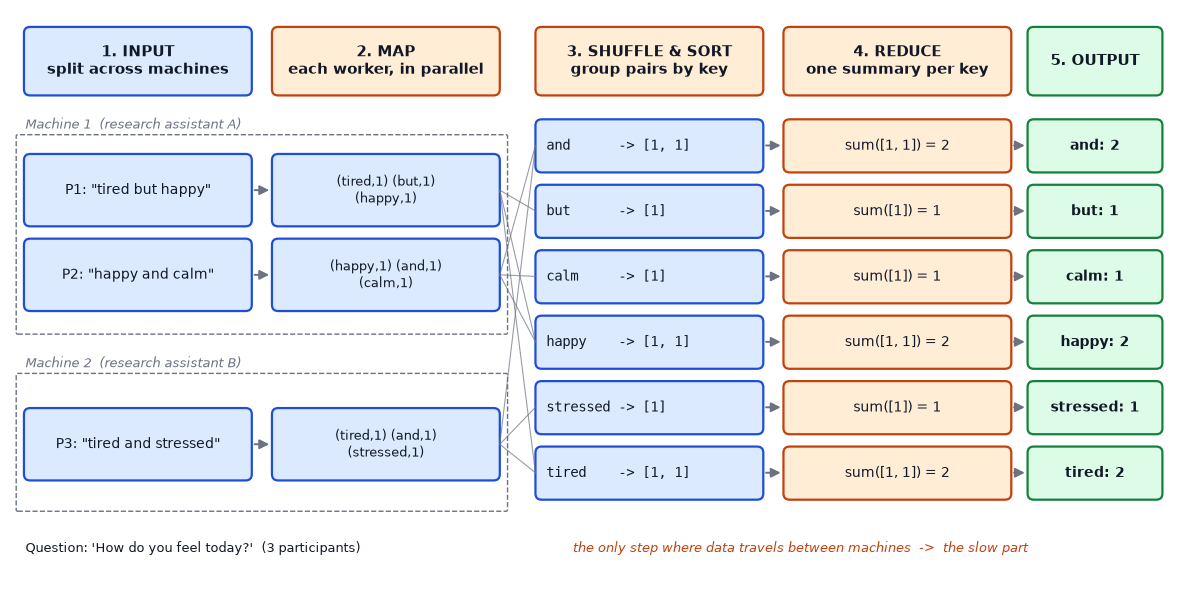

Three rules make this work:
- The mapper looks at one record at a time, so any number of machines can map in parallel
- Everything is a key-value pair, and the key decides which pile a value goes to
- Mappers and reducers are pure functions (week 2): if a machine crashes, we re-run its part and get the same answer

> Would this still work with 100 million answers? Yes: you add more assistants (machines). That is the whole point.

Mini glossary

| Term | Plain meaning | Research-methods analogy |
|------|---------------|--------------------------|
| key-value pair | a tuple `(label, value)`, e.g. `("happy", 1)` | a tally mark filed under a category |
| mapper | function that turns one record into key-value pairs | an assistant coding one interview |
| shuffle and sort | gathers all pairs with the same key into one pile | sorting coding sheets into piles by code |
| reducer | function that summarises one pile | counting (or averaging) one pile |
| node / worker | one computer in a cluster | one research assistant |
| cluster | many computers working as a team | the whole research team |

## 2) MapReduce by hand

We now run the drawing above in Python, one phase at a time, and print the result after each phase.

In [3]:
# 2.1 MAP: every answer -> a list of (word, 1) pairs

answers = ["tired but happy", "happy and calm", "tired and stressed"]

mapped = []
for answer in answers:
    for word in answer.split():
        mapped.append((word, 1))

print("After MAP:", mapped)

After MAP: [('tired', 1), ('but', 1), ('happy', 1), ('happy', 1), ('and', 1), ('calm', 1), ('tired', 1), ('and', 1), ('stressed', 1)]


In [4]:
# 2.2 SHUFFLE AND SORT: every pair with the same key goes into the same pile

piles = defaultdict(list)   # a dictionary where a new key starts with an empty list
for word, one in mapped:
    piles[word].append(one)

print("After SHUFFLE:", dict(sorted(piles.items())))

After SHUFFLE: {'and': [1, 1], 'but': [1], 'calm': [1], 'happy': [1, 1], 'stressed': [1], 'tired': [1, 1]}


In [5]:
# 2.3 REDUCE: one summary per pile

counts = {word: sum(ones) for word, ones in piles.items()}

print("After REDUCE:", dict(sorted(counts.items())))

After REDUCE: {'and': 2, 'but': 1, 'calm': 1, 'happy': 2, 'stressed': 1, 'tired': 2}


What should you notice?

- The result matches the green boxes in the drawing: `and: 2, but: 1, calm: 1, happy: 2, stressed: 1, tired: 2`
- The map step never looks at two answers at once, so each answer could be on a different machine
- The shuffle is the only step that needs all the pairs together

## 3) A reusable MapReduce "machine"

The shuffle never changes: it always groups by key.
Only the mapper and the reducer depend on the question we ask.

So we write the shuffle once, plus a function `run_mapreduce` that accepts any mapper and any reducer
(passing functions as arguments, a higher-order function like `map(f, data)` in week 2).

| Function | Who writes it? | Input | Output |
|----------|----------------|-------|--------|
| `map_func(record)` | you, for each question | one record | a list of `(key, value)` pairs |
| `shuffle_and_sort(pairs)` | written once, below | all pairs | `{key: [value1, value2, ...]}` |
| `reduce_func(key, values)` | you, for each question | one key and its pile | one `(key, result)` pair |

> Why is the shuffle expensive? On a real cluster every machine sends its pairs over the network to the machine responsible for each key. Here we have one computer, but the logic is identical.

In [6]:
# 3.1 The framework

def shuffle_and_sort(mapped_output):
    """Groups a list of (key, value) pairs into {key: [values]}."""
    grouped = defaultdict(list)
    for key, value in mapped_output:
        grouped[key].append(value)
    return dict(grouped)


def run_mapreduce(records, map_func, reduce_func):
    """Runs a full MapReduce job and returns a list of (key, result) pairs."""
    # 1. MAP: apply the mapper to every record (one record can give several pairs)
    mapped = []
    for record in records:
        mapped.extend(map_func(record))

    # 2. SHUFFLE AND SORT: group the values by key
    shuffled = shuffle_and_sort(mapped)

    # 3. REDUCE: apply the reducer to every pile
    return [reduce_func(key, values) for key, values in shuffled.items()]

In [7]:
# 3.2 Two small building blocks we will reuse all day

def word_mapper(text):
    return [(word, 1) for word in text.split()]

def sum_reducer(key, values):
    return (key, sum(values))

# Same toy answers as in section 2
run_mapreduce(answers, word_mapper, sum_reducer)

[('tired', 2),
 ('but', 1),
 ('happy', 2),
 ('and', 2),
 ('calm', 1),
 ('stressed', 1)]

Check: the same counts as in section 2 (the order may differ, which is fine).

## 4) Word count on 34,886 movie titles

Same job, bigger data. The only change is a slightly smarter mapper that cleans each title first:
- convert to lowercase (so "The" and "the" are the same word)
- remove punctuation

```
INPUT               MAP                SHUFFLE AND SORT            REDUCE
"The Dark Knight"   ("the", 1)         "the":    [1, 1, 1, ...]    ("the", 8672)
                    ("dark", 1)        "dark":   [1, 1, ...]       ("dark", ...)
                    ("knight", 1)      "knight": [1, ...]          ("knight", ...)
```

In [8]:
# 4.1 Word count on movie titles

def title_word_mapper(title):
    """One title -> one (word, 1) pair per word, after cleaning."""
    clean = title.strip().lower().translate(str.maketrans("", "", string.punctuation))
    return [(word, 1) for word in clean.split()]

results_titles = run_mapreduce(titles, title_word_mapper, sum_reducer)

top = sorted(results_titles, key=lambda pair: pair[1], reverse=True)   # largest count first
for word, count in top[:15]:
    print(f"{word:<10} {count}")

the        8672
of         2699
a          1219
in         1015
and        973
to         658
man        469
love       449
on         381
for        376
my         351
2          305
night      295
i          270
from       257


The top of the list is full of function words ("the", "of", "a", "in"): they carry grammar but little meaning
(the function-word vs content-word distinction from Linguagem e Cognição).
Lists of these words are called stop words, and NLTK has a ready-made list for English.

Only the mapper changes; the shuffle and the reducer stay exactly the same.

> On a real cluster, filtering inside the mapper also means fewer pairs travel through the slow shuffle.

In [9]:
# 4.2 The same job without stop words

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))
print("Stop words:", len(STOP_WORDS), "e.g.", sorted(STOP_WORDS)[:8])

def title_word_mapper_no_stopwords(title):
    """Same as title_word_mapper, but skips stop words."""
    clean = title.strip().lower().translate(str.maketrans("", "", string.punctuation))
    return [(word, 1) for word in clean.split() if word not in STOP_WORDS]

results_titles_clean = run_mapreduce(titles, title_word_mapper_no_stopwords, sum_reducer)

top_clean = sorted(results_titles_clean, key=lambda pair: pair[1], reverse=True)
for word, count in top_clean[:15]:
    print(f"{word:<10} {count}")

Stop words: 198 e.g. ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all']


man        469
love       449
2          305
night      295
girl       229
movie      215
life       189
last       184
big        177
story      175
lady       173
woman      173
black      171
little     168
one        166


Discussion:
- What does this tell us about people? Which themes do film titles return to again and again (man, love, night, girl, life, woman, lady...)? Is "man" more frequent than "woman"?
- These are films that have an English Wikipedia page. Who writes Wikipedia, and in which language? What kind of sampling bias does that introduce?

Possible answer:

- Titles return to love, relationships, life and night, classic narrative themes. "man" (469) clearly beats "woman" (173), consistent with the well-documented over-representation of male protagonists in film.
- The sample is not all films: it is films with an English Wikipedia plot summary, about half of them American. We can describe this corpus, but should be careful generalising to world cinema (a convenience sample).

## 5) Changing the key: movies per decade

The key does not have to be a column of the data: the mapper can create it.
Here we recode the release year into a decade (1994 -> "1990s"), just like "Recode into Different Variables" for age bands in SPSS.

- Map: `movie -> [(decade, 1)]`
- Reduce: `sum_reducer`, the same one as before

In [10]:
# 5.1 Movies per decade

def decade_of(movie):
    """1994 -> '1990s'. Returns 'Unknown' if the year is missing or not a number."""
    try:
        return f"{int(movie[YEAR_COL]) // 10 * 10}s"
    except (ValueError, TypeError):
        return "Unknown"

def decade_mapper(movie):
    return [(decade_of(movie), 1)]

results_decades = sorted(run_mapreduce(movies, decade_mapper, sum_reducer))   # sorted by decade

for decade, count in results_decades:
    print(f"{decade}  {count:>5}")

1900s     26
1910s    283
1920s    671
1930s   2310
1940s   2919
1950s   3414
1960s   2497
1970s   2519
1980s   3219
1990s   4468
2000s   5866
2010s   6694


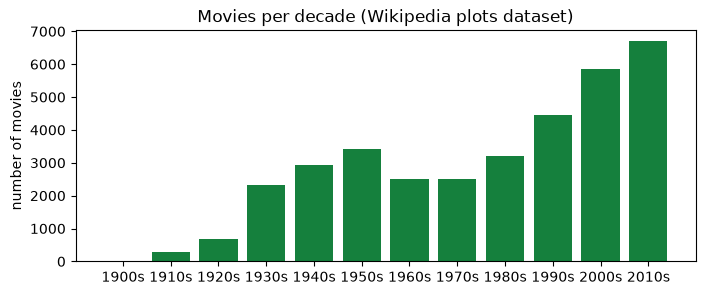

In [11]:
# 5.2 The same result as a picture

decades, counts = zip(*results_decades)
plt.figure(figsize=(8, 3))
plt.bar(decades, counts, color="#15803d")
plt.title("Movies per decade (Wikipedia plots dataset)")
plt.ylabel("number of movies")
plt.show()

Check: 12 decades, from `1900s` (26 movies) to `2010s` (6,694 movies).

Discussion:
- Does this show that more films were made in the 2010s, or that Wikipedia editors write more about recent films?
- How could you tell the two explanations apart?

Possible answer:

- Probably both. Film production did grow, but many early films are lost and less likely to have an article (survivorship and coverage bias).
- To separate them, compare with an independent count of films produced per decade (e.g. national film registries): a measure of the population, not just of this sample.

## 6) The reducer does not have to add

A reducer can do anything with its pile. Here it keeps the whole list, so we get an index genre -> titles,
like the index at the back of a textbook (topic -> pages).

In [12]:
# 6.1 Genre -> titles

def genre_title_mapper(movie):
    genre = str(movie[GENRE_COL]).strip().lower()
    return [(genre, str(movie[TITLE_COL]).strip())]

def list_reducer(key, values):
    return (key, sorted(values))   # keep the whole pile, alphabetically

genre_index = run_mapreduce(movies, genre_title_mapper, list_reducer)
genre_index = sorted(genre_index, key=lambda pair: len(pair[1]), reverse=True)   # biggest genres first

for genre, genre_titles in genre_index[:8]:
    print(f"{genre:<10} {len(genre_titles):>5} movies, e.g. {genre_titles[:2]}")

unknown     6083 movies, e.g. ['$ aka Dollars', "'71"]
drama       5991 movies, e.g. ["'68", "'Til We Meet Again"]
comedy      4398 movies, e.g. ["'Moms' Night Out", "'Neath Brooklyn Bridge"]
horror      1172 movies, e.g. ['12/12/12', '13 Eerie']
action      1119 movies, e.g. ["'Gator Bait II: Cajun Justice", '...tick...tick...tick...']
thriller     984 movies, e.g. ['"Pimpernel" Smith', '10 Kalpanakal']
romance      940 movies, e.g. ['100 Days of Love', '100% Love']
western      865 movies, e.g. ['100 Rifles', '3 Godfathers']


What should you notice?

- The biggest "genre" is `unknown`: about 6,000 movies, 17% of the data
- Before counting anything, always ask how much is missing and whether it is missing at random, exactly as with missing questionnaire answers (veracity)

## 7) The averaging trap: why reducers carry (sum, count)

Counting is easy because counts can simply be added. Averages cannot.

Imagine a Stroop experiment whose trials are stored on two machines.
To save network traffic, real systems let each machine pre-summarise its own data before the shuffle.
If each machine sends its mean, the final answer is wrong:

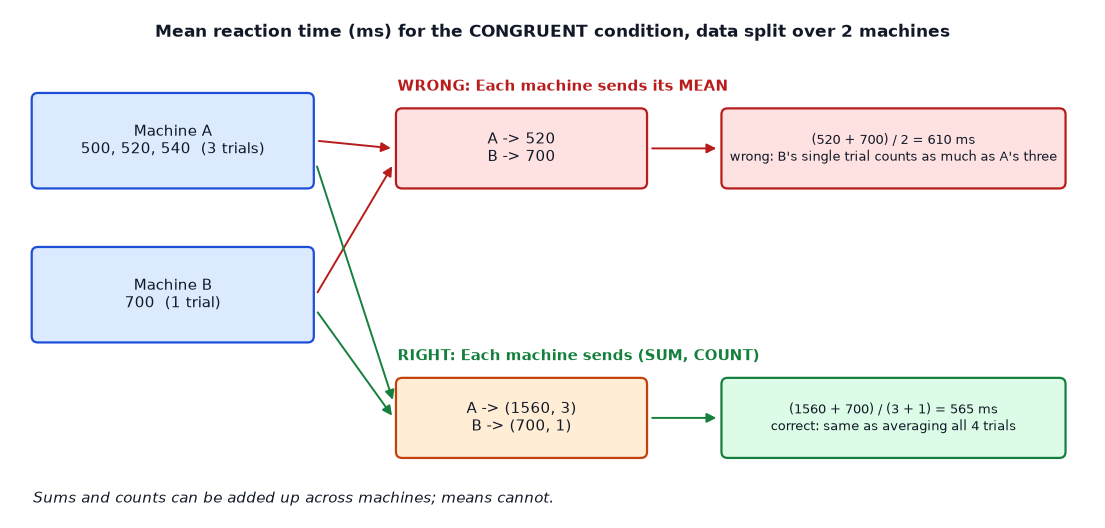

This is the same reason you cannot average the means of two groups of different sizes without weighting them.

In [13]:
# 7.1 The trap in numbers

# Toy Stroop data: (condition, reaction time in ms). Each list lives on a different machine.
machine_A = [("congruent", 500), ("congruent", 520), ("congruent", 540), ("incongruent", 650)]
machine_B = [("congruent", 700), ("incongruent", 690), ("incongruent", 710)]

mean_A = (500 + 520 + 540) / 3
mean_B = 700 / 1
print("Average of the machine means:", (mean_A + mean_B) / 2, "ms (wrong)")
print("True mean of all trials:     ", (500 + 520 + 540 + 700) / 4, "ms (right)")

Average of the machine means: 610.0 ms (wrong)
True mean of all trials:      565.0 ms (right)


The fix: the mapper emits the value as a pair `(reaction_time, 1)`.
Sums and counts can be added safely on any machine, in any order, and we divide only at the very end.

```
MAP emits:       ("congruent", (500, 1)), ("congruent", (520, 1)), ...
SHUFFLE gives:   "congruent" -> [(500, 1), (520, 1), (540, 1), (700, 1)]
REDUCE does:     total = 2260, count = 4  ->  2260 / 4 = 565 ms
```

In [14]:
# 7.2 Mean reaction time per condition with (sum, count)

trials = machine_A + machine_B

def rt_mapper(trial):
    condition, rt = trial
    return [(condition, (rt, 1))]   # value = (reaction time, one trial)

def mean_reducer(key, values):
    """values is a list of (amount, count) pairs -> returns (key, mean)."""
    total = sum(amount for amount, n in values)
    count = sum(n for amount, n in values)
    return (key, round(total / count, 1))

print(run_mapreduce(trials, rt_mapper, mean_reducer))

# The same result with pandas groupby, which you already know
pd.DataFrame(trials, columns=["condition", "rt"]).groupby("condition")["rt"].mean().round(1)

[('congruent', 565.0), ('incongruent', 683.3)]


condition
congruent      565.0
incongruent    683.3
Name: rt, dtype: float64

What should you notice?

- `congruent` -> 565.0 ms and `incongruent` -> 683.3 ms, and pandas agrees
- The Stroop effect in this toy data is about 118 ms
- This "carry partial results" pattern comes back in Spark next week (`reduceByKey`, `agg`)

## 8) Chaining two jobs

Some questions need two groupings. Example: "in each decade, which director made the most films?"
- First we group by (decade, director) to count films
- Then we group by decade alone to pick the maximum

Each grouping needs its own shuffle, so we chain two MapReduce jobs: the output of Job 1 is the input of Job 2.

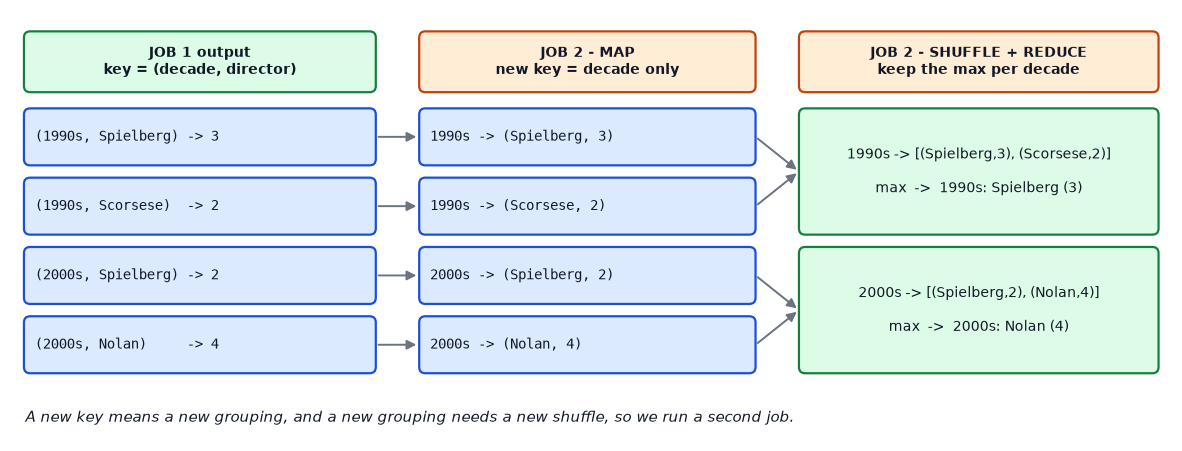

> A new key means a new grouping, and a new grouping means a new shuffle. On a cluster, every extra job costs another round of network traffic.

## 9) Exercises

Replace every `# TODO` with your own code, then run the cell.
Each exercise shows the expected output so you can check yourself.

### Exercise 1 (Practice): average plot length per origin

Task
- For each `Origin/Ethnicity`, compute the average number of words in the plot summary
- Print the 10 origins with the longest plots

Hints
- This is exactly the Stroop example from section 7 with different names:

| Stroop (section 7) | Movies (now) |
|--------------------|--------------|
| condition | `ORIGIN_COL` |
| reaction time | number of words in `PLOT_COL` |
| `mean_reducer` | `mean_reducer` (reuse it) |

In [15]:
# Exercise 1 (solution)

def plot_length_mapper(movie):
    origin = str(movie[ORIGIN_COL]).strip()
    word_count = len(str(movie[PLOT_COL]).split())   # number of words in this plot
    return [(origin, (word_count, 1))]

results_ex1 = run_mapreduce(movies, plot_length_mapper, mean_reducer)

for origin, avg in sorted(results_ex1, key=lambda pair: pair[1], reverse=True)[:10]:
    print(f"{origin:<12} {avg:>6.1f} words")

Japanese      445.5 words
American      421.7 words
Filipino      389.7 words
Hong Kong     359.3 words
Bollywood     342.6 words
Russian       340.4 words
Telugu        336.1 words
Chinese       331.4 words
British       329.5 words
Canadian      324.1 words


Expected output (first 3 lines):
```
Japanese      445.5 words
American      421.7 words
Filipino      389.7 words
```

Discussion: do Japanese films really have more complex stories? Think about operationalisation: what does "number of words in a Wikipedia summary" actually measure?

Possible answer:

It measures how much a Wikipedia editor chose to write. That depends on the editor's enthusiasm, the film's popularity among English-speaking fans (e.g. anime) and the editing culture, not only on the story. Summary length is a weak indicator of story complexity (low construct validity).

### Exercise 2 (Practice): most prolific director per decade

Task
- Find the director with the most films in each decade, using two chained jobs (section 8)
- Task A: Job 1 counts films per `(decade, director)`
- Task B: Job 2 keeps the top director of each decade

Some films have several directors (`"George S. Fleming, Edwin S. Porter"`) and many have `"Unknown"`.
The helper `split_directors` below is already written: it splits the names and skips unknown ones.

In [16]:
# 9.1 Helper: split the Director field into a list of names

def split_directors(movie):
    """'George S. Fleming, Edwin S. Porter' -> ['George S. Fleming', 'Edwin S. Porter'] (skips unknown/missing)."""
    names = [name.strip() for name in str(movie[DIRECTOR_COL]).split(",")]
    return [name for name in names if name.lower() not in ("", "unknown", "nan", "various")]

print(split_directors({DIRECTOR_COL: "George S. Fleming, Edwin S. Porter"}))
print(split_directors({DIRECTOR_COL: "Unknown"}))

['George S. Fleming', 'Edwin S. Porter']
[]


Task A: Job 1, count films per (decade, director)

Hints
- The key is a tuple of two things: `(decade, director)`
- `decade_of` comes from section 5
- Is there a reducer from section 3 that already sums a pile?

In [17]:
# Exercise 2A (solution)

def director_decade_mapper(movie):
    decade = decade_of(movie)
    pairs = []
    for director in split_directors(movie):
        pairs.append(((decade, director), 1))
    return pairs

job1 = run_mapreduce(movies, director_decade_mapper, sum_reducer)

print(len(job1), "different (decade, director) combinations")
print(job1[:3])

17693 different (decade, director) combinations
[(('1900s', 'George S. Fleming'), 1), (('1900s', 'Edwin S. Porter'), 3), (('1900s', 'Cecil Hepworth'), 1)]


Expected output:
```
17693 different (decade, director) combinations
[(('1900s', 'George S. Fleming'), 1), (('1900s', 'Edwin S. Porter'), 3), (('1900s', 'Cecil Hepworth'), 1)]
```

Task B: Job 2, keep the top director of each decade

Hints
- Move the director from the key into the value, so the new key is the decade alone (see the drawing in section 8)
- The input of Job 2 is the output of Job 1

In [18]:
# Exercise 2B (solution)

def top_director_mapper(record):
    (decade, director), n_films = record   # unpack one result of Job 1
    return [(decade, (director, n_films))]

def top_director_reducer(key, values):
    best_director, best_count = max(values, key=lambda pair: pair[1])   # pair = (director, n_films)
    return (key, f"{best_director} ({best_count} films)")

job2 = run_mapreduce(job1, top_director_mapper, top_director_reducer)

for decade, info in sorted(job2):
    print(f"{decade} -> {info}")

1900s -> D. W. Griffith (7 films)
1910s -> Cecil B. DeMille (22 films)
1920s -> Buster Keaton (23 films)
1930s -> Michael Curtiz (39 films)
1940s -> Jules White (27 films)
1950s -> Hanna-Barbera (51 films)
1960s -> Roger Corman (18 films)
1970s -> K. Balachander (21 films)
1980s -> S. P. Muthuraman (25 films)
1990s -> Mahesh Bhatt (19 films)
2000s -> Johnnie To (17 films)
2010s -> Ram Gopal Varma (13 films)


Expected output (first 4 lines):
```
1900s -> D. W. Griffith (7 films)
1910s -> Cecil B. DeMille (22 films)
1920s -> Buster Keaton (23 films)
1930s -> Michael Curtiz (39 films)
```

| Part | Role |
|------|------|
| Job 1 key `(decade, director)` | one pile per director in each decade, so we can count their films |
| Job 2 key `decade` | one pile per decade, containing every director of that decade |
| `max(values, key=...)` | inside one decade's pile, keep the pair with the largest count |

Discussion (veracity):
- If we had not skipped `"Unknown"`, "Unknown" would win every decade from the 1940s onwards. Why?
- Look at the 1950s winner. Is it a person? What does that say about trusting a column called `Director`?

Possible answer:

- All films with a missing director are pooled into one giant "Unknown" pile, which outnumbers any real person. It is a missing-data code, not a director.
- The 1950s winner, Hanna-Barbera, is an animation studio (many short cartoons), not a person. Column names describe what the data should contain, not what it does contain, so always inspect the top results before interpreting them.

### Exercise 3 (Challenge (optional)): directors with the most different genres

Task
- Find the 10 directors who worked in the largest number of different genres

This is the classic "count distinct" problem.
If we simply emitted `(director, 1)` per film, a director with 10 westerns would get 10 points for one genre.
We first need the unique `(director, genre)` pairs:

```
JOB 1   MAP:    ((director, genre), 1)     composite key: the shuffle removes duplicates for us
        REDUCE: (director, 1)              ONE point per unique pair, however many films
JOB 2   MAP:    (director, 1)              already in the right shape: pass it through
        REDUCE: (director, number_of_genres)
```

Hints
- Reuse `split_directors` from Exercise 2
- For Job 2, the mapper only has to put the record in a list: `lambda record: [record]`

In [19]:
# Exercise 3 (solution)

# JOB 1: unique (director, genre) pairs
def director_genre_mapper(movie):
    genre = str(movie[GENRE_COL]).strip().lower()
    return [((director, genre), 1) for director in split_directors(movie)]

def dedup_reducer(key, values):
    director, genre = key
    return (director, 1)   # one point per unique (director, genre), however many films

job1_ex3 = run_mapreduce(movies, director_genre_mapper, dedup_reducer)

# JOB 2: add up the points per director
job2_ex3 = run_mapreduce(job1_ex3, lambda record: [record], sum_reducer)

for director, n_genres in sorted(job2_ex3, key=lambda pair: pair[1], reverse=True)[:10]:
    print(f"{director:<20} {n_genres} genres")

Michael Curtiz       29 genres
Lloyd Bacon          27 genres
Mervyn LeRoy         24 genres
Gordon Douglas       22 genres
Henry Hathaway       21 genres
Jack Conway          20 genres
Richard Fleischer    20 genres
Alfred E. Green      19 genres
Howard Hawks         19 genres
W. S. Van Dyke       19 genres


Expected output (first 3 lines):
```
Michael Curtiz       29 genres
Lloyd Bacon          27 genres
Mervyn LeRoy         24 genres
```

> **BONUS:** print the top 20 instead of the top 10. One "director" is called `Jr.`: where does it come from, and how would you fix `split_directors`?

Possible answer:
- Names like `"George Nicholls, Jr."` are split at the comma, so `Jr.` becomes a separate "director" that collects points from every Jr. in the dataset. A fix is to glue suffixes such as `Jr.` and `Sr.` back onto the previous name.
- The `Genre` column also mixes single and combined labels ("comedy" vs "comedy, drama"), and `unknown` counts as a genre, so "number of genres" is inflated. Cleaning categories is a coding decision, like building a codebook for open answers.

## 10) Summary

| Question | Key | Value | Reducer |
|----------|-----|-------|---------|
| How often is each word used? | word | `1` | sum |
| How many films per decade? | decade (created by the mapper) | `1` | sum |
| Which films per genre? | genre | title | keep the list |
| Mean RT or plot length per group? | group | `(amount, 1)` | sum both, divide at the end |
| Top director per decade? | Job 1: `(decade, director)`, Job 2: `decade` | `1`, then `(director, count)` | sum, then max |

Take-home ideas:
- Choose the key well: it decides what gets grouped together
- Only the mapper and the reducer change; the shuffle is always the same, and always the slowest part
- Carry partial results (sum, count), never averages
- New grouping -> new shuffle -> new job
- Big data does not remove the need for data quality checks (unknowns, studios, `Jr.`)

Next week: Spark. The same word count looks like this, and Spark takes care of the machines and the shuffle:
```python
rdd.flatMap(lambda title: [(w, 1) for w in title.lower().split()]) \
   .reduceByKey(lambda a, b: a + b)
```

Discussion: think of a dataset from your own field (experience-sampling pings, eye-tracking samples, social media posts...). What question would you ask, and what would the key and the value be?

___

This notebook was adapted for ISPA from the NOVA IMS Big Data Analysis week 3 lab (`map_reduce_students.ipynb`). Reference: Dean, J., & Ghemawat, S. (2004). MapReduce: Simplified data processing on large clusters.